In [25]:
from os import listdir
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FileNames = listdir('Speeches')

speech_df = pd.DataFrame(index=range(len(FileNames)),
                         columns=['FileName','Content'])
for i, f_name in enumerate(FileNames):
    #open the file as read only in utf-8 format
    f = open('Speeches/' + f_name, 'r', encoding='utf-8') 
    # read the lines of the file and assign it to f_content
    f_content = f.readlines()
    # close the file
    f.close()
    # assign the file name to the the FileName attribute
    speech_df.at[i, 'FileName'] = f_name
    # assign the content to the content attribute
    speech_df.at[i, 'Content'] = f_content[0]
speech_df.head()

,FileName,Content
0,BattleCreekDec19_2019.txt,Thank you. Thank you. Thank you to Vice Presid...
1,BemidjiSep18_2020.txt,There's a lot of people. That's great. Thank y...
2,CharlestonFeb28_2020.txt,Thank you. Thank you. Thank you. All I can say...
3,CharlotteMar2_2020.txt,"I want to thank you very much. North Carolina,..."
4,CincinnatiAug1_2019.txt,Thank you all. Thank you very much. Thank you ...


### Unpack file name

In [26]:
Months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
def SeperateCity(v):
    for mon in Months:
        if (mon in v):
            return v[:v.find(mon)]
speech_df['City'] = speech_df['FileName'].apply(SeperateCity)

In [27]:
speech_df.head()

,FileName,Content,City
0,BattleCreekDec19_2019.txt,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek
1,BemidjiSep18_2020.txt,There's a lot of people. That's great. Thank y...,Bemidji
2,CharlestonFeb28_2020.txt,Thank you. Thank you. Thank you. All I can say...,Charleston
3,CharlotteMar2_2020.txt,"I want to thank you very much. North Carolina,...",Charlotte
4,CincinnatiAug1_2019.txt,Thank you all. Thank you very much. Thank you ...,Cincinnati


In [28]:
df = 'BattleCreekDec19_2019.txt'
df[:df.find('Dec')]

'BattleCreek'

In [29]:
type(df)

str

In [30]:
def SeperateDate(r):
    return r['FileName'][len(r['City']):r['FileName'].find('.txt')]
speech_df['Date']=speech_df.apply(SeperateDate, axis=1)

In [31]:
speech_df.head()

,FileName,Content,City,Date
0,BattleCreekDec19_2019.txt,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek,Dec19_2019
1,BemidjiSep18_2020.txt,There's a lot of people. That's great. Thank y...,Bemidji,Sep18_2020
2,CharlestonFeb28_2020.txt,Thank you. Thank you. Thank you. All I can say...,Charleston,Feb28_2020
3,CharlotteMar2_2020.txt,"I want to thank you very much. North Carolina,...",Charlotte,Mar2_2020
4,CincinnatiAug1_2019.txt,Thank you all. Thank you very much. Thank you ...,Cincinnati,Aug1_2019


In [32]:
speech_df['Date']=pd.to_datetime(speech_df['Date'], format='%b%d_%Y')

In [33]:
speech_df.head()

,FileName,Content,City,Date
0,BattleCreekDec19_2019.txt,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek,2019-12-19
1,BemidjiSep18_2020.txt,There's a lot of people. That's great. Thank y...,Bemidji,2020-09-18
2,CharlestonFeb28_2020.txt,Thank you. Thank you. Thank you. All I can say...,Charleston,2020-02-28
3,CharlotteMar2_2020.txt,"I want to thank you very much. North Carolina,...",Charlotte,2020-03-02
4,CincinnatiAug1_2019.txt,Thank you all. Thank you very much. Thank you ...,Cincinnati,2019-08-01


In [34]:
def extractDMY(r):
    r['Day']=r['Date'].day
    r['Month']=r['Date'].month
    r['Year']=r['Date'].year
    return r
speech_df = speech_df.apply(extractDMY, axis=1)

In [35]:
speech_df.head()

,FileName,Content,City,Date,Day,Month,Year
0,BattleCreekDec19_2019.txt,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek,2019-12-19,19,12,2019
1,BemidjiSep18_2020.txt,There's a lot of people. That's great. Thank y...,Bemidji,2020-09-18,18,9,2020
2,CharlestonFeb28_2020.txt,Thank you. Thank you. Thank you. All I can say...,Charleston,2020-02-28,28,2,2020
3,CharlotteMar2_2020.txt,"I want to thank you very much. North Carolina,...",Charlotte,2020-03-02,2,3,2020
4,CincinnatiAug1_2019.txt,Thank you all. Thank you very much. Thank you ...,Cincinnati,2019-08-01,1,8,2019


In [36]:
speech_df.drop(columns=['FileName'], inplace=True)

In [37]:
speech_df.head()

,Content,City,Date,Day,Month,Year
0,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek,2019-12-19,19,12,2019
1,There's a lot of people. That's great. Thank y...,Bemidji,2020-09-18,18,9,2020
2,Thank you. Thank you. Thank you. All I can say...,Charleston,2020-02-28,28,2,2020
3,"I want to thank you very much. North Carolina,...",Charlotte,2020-03-02,2,3,2020
4,Thank you all. Thank you very much. Thank you ...,Cincinnati,2019-08-01,1,8,2019


### Unpack content

In [38]:
words = ['vote','tax','campaign','economy']
def FindWordRatio(row):
    total_n_words = len(row['Content'].split(' '))
    for w in words:
        row['r_{}'.format(w)] = row['Content'].count(w)/total_n_words
    return row
speech_df = speech_df.apply(FindWordRatio, axis=1)

In [39]:
speech_df['Content'][1].count('vote')

12

In [40]:
type(speech_df['Content'][1])

str

In [41]:
speech_df.head()

,Content,City,Date,Day,Month,Year,r_vote,r_tax,r_campaign,r_economy
0,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek,2019-12-19,19,12,2019,0.000561,0.000505,0.000224,0.000617
1,There's a lot of people. That's great. Thank y...,Bemidji,2020-09-18,18,9,2020,0.000710,0.000237,0.000533,0.000000
2,Thank you. Thank you. Thank you. All I can say...,Charleston,2020-02-28,28,2,2020,0.000950,0.000317,0.000106,0.000000
3,"I want to thank you very much. North Carolina,...",Charlotte,2020-03-02,2,3,2020,0.000750,0.001500,0.000150,0.000450
4,Thank you all. Thank you very much. Thank you ...,Cincinnati,2019-08-01,1,8,2019,0.001713,0.000857,0.001224,0.000245


In [42]:
Months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# Months[r['Month']-1] takes the month value from row and then finds the index number of Months list
# minus one is used because list goes from 0 to 11 and the Month attribute goes from 1 to 12
lambda_func = lambda r: '{}_{}'.format(r['Year'], Months[r['Month']-1])

In [43]:
speech_df['Y_M']=speech_df.apply(lambda_func, axis=1)

In [44]:
speech_df.head()

,Content,City,Date,Day,Month,Year,r_vote,r_tax,r_campaign,r_economy,Y_M
0,Thank you. Thank you. Thank you to Vice Presid...,BattleCreek,2019-12-19,19,12,2019,0.000561,0.000505,0.000224,0.000617,2019_Dec
1,There's a lot of people. That's great. Thank y...,Bemidji,2020-09-18,18,9,2020,0.000710,0.000237,0.000533,0.000000,2020_Sep
2,Thank you. Thank you. Thank you. All I can say...,Charleston,2020-02-28,28,2,2020,0.000950,0.000317,0.000106,0.000000,2020_Feb
3,"I want to thank you very much. North Carolina,...",Charlotte,2020-03-02,2,3,2020,0.000750,0.001500,0.000150,0.000450,2020_Mar
4,Thank you all. Thank you very much. Thank you ...,Cincinnati,2019-08-01,1,8,2019,0.001713,0.000857,0.001224,0.000245,2019_Aug


In [45]:
Words = ['vote','tax','campaign','economy']
vis_df = speech_df.pivot_table(index=['Y_M'], values = ['r_{}'.format (w) for w in words], aggfunc=np.mean)

In [46]:
vis_df.head()

,r_campaign,r_economy,r_tax,r_vote
Y_M,,,,
2019_Aug,0.001499,0.000270,0.000872,0.001596
2019_Dec,0.000316,0.000665,0.000558,0.000739
2019_Jul,0.000283,0.000660,0.000660,0.001603
2019_Nov,0.000551,0.000333,0.000385,0.002048
2019_Oct,0.000843,0.000448,0.000419,0.000409


In [47]:
vis_df2 = pd.DataFrame({
    'r_vote':speech_df.groupby('Y_M').r_vote.mean(),
    'r_tax':speech_df.groupby('Y_M').r_tax.mean(),
    'r_campaign':speech_df.groupby('Y_M').r_campaign.mean(),
    'r_ecomony':speech_df.groupby('Y_M').r_economy.mean()})

In [48]:
vis_df2.head()

,r_vote,r_tax,r_campaign,r_ecomony
Y_M,,,,
2019_Aug,0.001596,0.000872,0.001499,0.000270
2019_Dec,0.000739,0.000558,0.000316,0.000665
2019_Jul,0.001603,0.000660,0.000283,0.000660
2019_Nov,0.002048,0.000385,0.000551,0.000333
2019_Oct,0.000409,0.000419,0.000843,0.000448


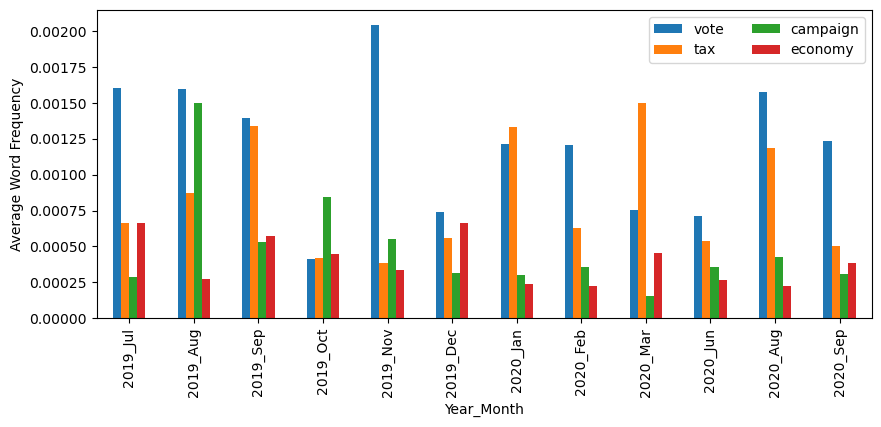

In [49]:
import matplotlib.pyplot as plt
column_order = vis_df.sum().sort_values(ascending=False).index
row_order = speech_df.sort_values('Date')['Y_M'].unique()
vis_df[column_order].loc[row_order].plot.bar(figsize=(10,4))
plt.legend(['vote','tax','campaign','economy'], ncol=2)
plt.xlabel('Year_Month')
plt.ylabel('Average Word Frequency')
plt.show()

In [50]:
row_order

array(['2019_Jul', '2019_Aug', '2019_Sep', '2019_Oct', '2019_Nov',
       '2019_Dec', '2020_Jan', '2020_Feb', '2020_Mar', '2020_Jun',
       '2020_Aug', '2020_Sep'], dtype=object)

In [51]:
column_order

Index(['r_vote', 'r_tax', 'r_campaign', 'r_economy'], dtype='object')

In [52]:
customer_df = pd.read_csv('Customer Churn.csv')
customer_df.head()

,Call Failure,Complains,Subscription Length,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Status,Churn
0,8,0,38,4370,71,5,17,1,0
1,0,0,39,318,5,7,4,0,0
2,10,0,37,2453,60,359,24,1,0
3,10,0,38,4198,66,1,35,1,0
4,3,0,38,2393,58,2,33,1,0


In [53]:
customer_df.columns = ['Call_Failure','Complains','Subscription_Length','Seconds_Of_Use',
                       'Frequency_of_use','Frequency_of_SMS','Distinct_Called_Numbers','Status','Churn']

In [54]:
customer_df.head()

,Call_Failure,Complains,Subscription_Length,Seconds_Of_Use,Frequency_of_use,Frequency_of_SMS,Distinct_Called_Numbers,Status,Churn
0,8,0,38,4370,71,5,17,1,0
1,0,0,39,318,5,7,4,0,0
2,10,0,37,2453,60,359,24,1,0
3,10,0,38,4198,66,1,35,1,0
4,3,0,38,2393,58,2,33,1,0


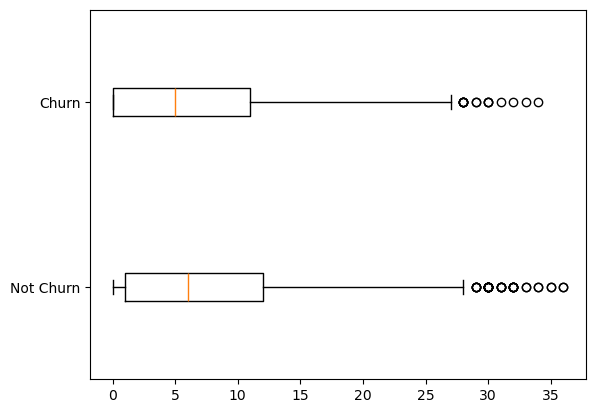

In [55]:
churn_possibilities = customer_df['Churn'].unique()
box_sr = pd.Series('', index=churn_possibilities)
for poss in churn_possibilities:
    BM = customer_df['Churn'] == poss
    box_sr[poss] = customer_df[BM].Call_Failure.values
plt.boxplot(box_sr, vert=False)
plt.yticks([1,2],['Not Churn','Churn'])
plt.show()

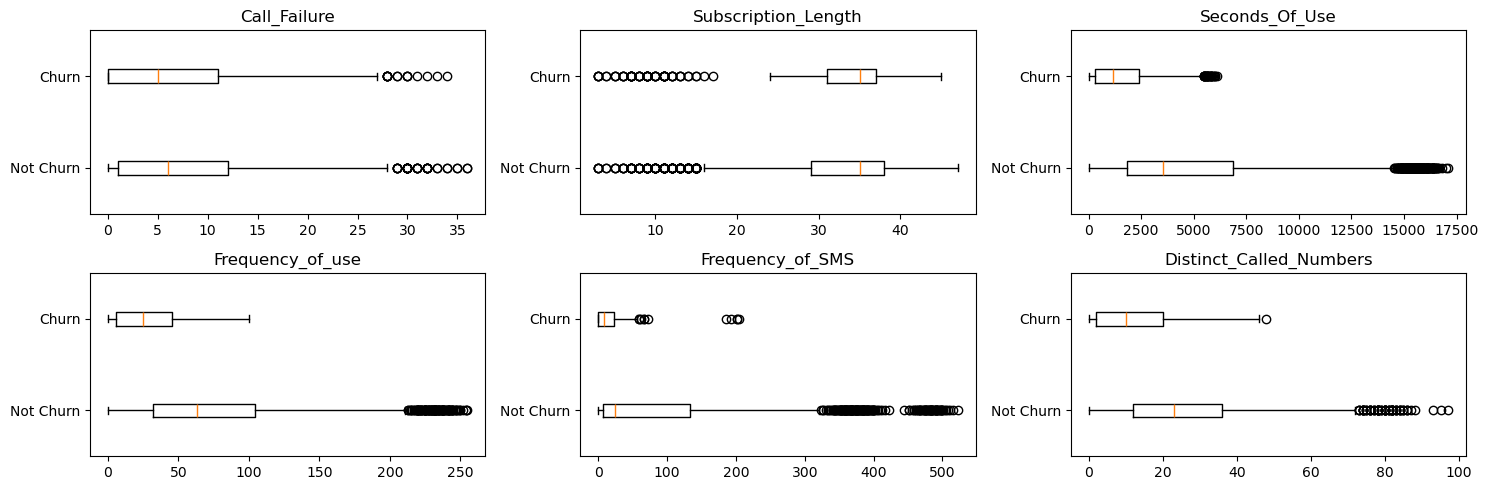

In [56]:
select_columns = ['Call_Failure','Subscription_Length','Seconds_Of_Use',
                  'Frequency_of_use','Frequency_of_SMS','Distinct_Called_Numbers']
churn_possibilities = customer_df['Churn'].unique()
plt.figure(figsize=(15,5))
for i, sc in enumerate(select_columns):
    for poss in churn_possibilities:
        BM = customer_df['Churn'] == poss
        box_sr[poss] = customer_df[BM][sc].values
    plt.subplot(2,3,i+1)
    plt.boxplot(box_sr, vert=False)
    plt.yticks([1,2],['Not Churn','Churn'])
    plt.title(sc)
plt.tight_layout()
plt.show()
    

In [57]:
month_df = pd.read_csv('Electric_Production.csv')
month_df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [58]:
month_df.columns = ['Date','Demand']
month_df.set_index(pd.to_datetime(month_df['Date'], format='%m/%d/%Y'), inplace=True)
month_df.drop(columns=['Date'], inplace=True)

In [59]:
month_df.head()

,Demand
Date,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [60]:
attributes_dic = {'IA1':'Average demand of the month',
                  'IA2':'Slope of change for the demand of the month',
                  'IA3':'Average demand of the months t-2, t-3, t-4',
                  'DA':'Demand of month t'}
predict_df = pd.DataFrame(index=month_df.iloc[24:].index, columns=attributes_dic.keys())

In [61]:
predict_df.head()

,IA1,IA2,IA3,DA
Date,,,,
1987-01-01,NaN,NaN,NaN,NaN
1987-02-01,NaN,NaN,NaN,NaN
1987-03-01,NaN,NaN,NaN,NaN
1987-04-01,NaN,NaN,NaN,NaN
1987-05-01,NaN,NaN,NaN,NaN


In [62]:
predict_df.DA = month_df['1987-01-01':]['Demand']
predict_df.head()

,IA1,IA2,IA3,DA
Date,,,,
1987-01-01,NaN,NaN,NaN,73.8152
1987-02-01,NaN,NaN,NaN,70.0620
1987-03-01,NaN,NaN,NaN,65.6100
1987-04-01,NaN,NaN,NaN,60.1586
1987-05-01,NaN,NaN,NaN,58.8734


In [63]:
month_df.head()

,Demand
Date,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [64]:
# v.month takes the index value from month_df.index and returns the month number only
# for v in month_df.index: return v.month # moth number
month_df['Month']= list(map(lambda v: v.month, month_df.index))

In [65]:
month_df.head()

,Demand,Month
Date,,
1985-01-01,72.5052,1
1985-02-01,70.6720,2
1985-03-01,62.4502,3
1985-04-01,57.4714,4
1985-05-01,55.3151,5


In [66]:
month_df.index[1].month

2

In [67]:
def ComputeAI1(r):
    row_date = r.name
    #print(r.name)
    wdf = month_df.loc[:row_date].iloc[:-1]
    #print(wdf)
    BM = wdf['Month'] == row_date.month
    return wdf[BM].Demand.mean()
predict_df.IA1 = predict_df.apply(ComputeAI1, axis=1)

              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2001-11-01   82.9319     11
2001-12-01   93.0381     12
2002-01-01  102.9955      1
2002-02-01   95.2075      2
2002-03-01   93.2556      3

[207 rows x 2 columns]
2002-05-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2001-12-01   93.0381     12
2002-01-01  102.9955      1
2002-02-01   95.2075      2
2002-03-01   93.2556      3
2002-04-01   85.7950      4

[208 rows x 2 columns]
2002-06-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.

              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2006-08-01  111.5192      8
2006-09-01   95.7632      9
2006-10-01   90.3738     10
2006-11-01   92.3566     11
2006-12-01  103.0660     12

[264 rows x 2 columns]
2007-02-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2006-09-01   95.7632      9
2006-10-01   90.3738     10
2006-11-01   92.3566     11
2006-12-01  103.0660     12
2007-01-01  112.0576      1

[265 rows x 2 columns]
2007-03-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.

2011-02-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2010-09-01  100.1209      9
2010-10-01   88.9251     10
2010-11-01   92.7750     11
2010-12-01  114.3266     12
2011-01-01  119.4880      1

[313 rows x 2 columns]
2011-03-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2010-10-01   88.9251     10
2010-11-01   92.7750     11
2010-12-01  114.3266     12
2011-01-01  119.4880      1
2011-02-01  107.3753      2

[314 rows x 2 columns]
2011-04-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714    

              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2015-09-01  101.9204      9
2015-10-01   91.5959     10
2015-11-01   93.0628     11
2015-12-01  103.2203     12
2016-01-01  117.0837      1

[373 rows x 2 columns]
2016-03-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.3151      5
...              ...    ...
2015-10-01   91.5959     10
2015-11-01   93.0628     11
2015-12-01  103.2203     12
2016-01-01  117.0837      1
2016-02-01  106.6688      2

[374 rows x 2 columns]
2016-04-01 00:00:00
              Demand  Month
Date                       
1985-01-01   72.5052      1
1985-02-01   70.6720      2
1985-03-01   62.4502      3
1985-04-01   57.4714      4
1985-05-01   55.

In [68]:
predict_df.head()

,IA1,IA2,IA3,DA
Date,,,,
1987-01-01,72.90545,NaN,NaN,73.8152
1987-02-01,69.32945,NaN,NaN,70.0620
1987-03-01,62.33615,NaN,NaN,65.6100
1987-04-01,57.25215,NaN,NaN,60.1586
1987-05-01,55.56440,NaN,NaN,58.8734


In [69]:
month_df.loc[:'1987-01-01'].iloc[:-1]

,Demand,Month
Date,,
1985-01-01,72.5052,1
1985-02-01,70.6720,2
1985-03-01,62.4502,3
1985-04-01,57.4714,4
1985-05-01,55.3151,5
1985-06-01,58.0904,6
1985-07-01,62.6202,7
1985-08-01,63.2485,8
1985-09-01,60.5846,9


In [70]:
from sklearn.linear_model import LinearRegression
def ComputeAI2(r):
    row_date = r.name
    wdf = month_df.loc[:row_date].iloc[:-1]
    BM = wdf.Month == row_date.month
    wdf = wdf[BM]
    wdf.reset_index(drop=True, inplace=True)
    wdf.drop(columns = ['Month'],inplace=True)
    wdf['integer'] = range(len(wdf))
    wdf['ones'] = 1
    lm = LinearRegression()
    lm.fit(wdf.drop(columns=['Demand']), wdf['Demand'])
    return lm.coef_[0]
predict_df['IA2'] = predict_df.apply(ComputeAI2, axis=1)
    

In [71]:
predict_df.head()

,IA1,IA2,IA3,DA
Date,,,,
1987-01-01,72.90545,0.8005,NaN,73.8152
1987-02-01,69.32945,-2.6851,NaN,70.0620
1987-03-01,62.33615,-0.2281,NaN,65.6100
1987-04-01,57.25215,-0.4385,NaN,60.1586
1987-05-01,55.56440,0.4986,NaN,58.8734


In [72]:
def ComputeIA3(r):
    row_date = r.name
    wdf = month_df.loc[:row_date].iloc[-5:-2]
    return wdf.Demand.mean()
predict_df['IA3'] = predict_df.apply(ComputeIA3, axis=1)

In [73]:
predict_df.head()

,IA1,IA2,IA3,DA
Date,,,,
1987-01-01,72.90545,0.8005,59.291467,73.8152
1987-02-01,69.32945,-2.6851,61.669767,70.0620
1987-03-01,62.33615,-0.2281,67.097433,65.6100
1987-04-01,57.25215,-0.4385,70.670867,60.1586
1987-05-01,55.56440,0.4986,69.829067,58.8734


In [74]:
from sklearn.linear_model import LinearRegression
x = predict_df.drop(columns=['DA'])
y = predict_df['DA']
lm = LinearRegression()
lm.fit(x,y)
print('intercept (b0) ', lm.intercept_)
coef_names = ['b1','b2','b3']
print(pd.DataFrame({'Predictor': x.columns,
                    'coefficient Name': coef_names,
                    'coefficient Value': lm.coef_}))

intercept (b0)  -25.752948794014728
  Predictor coefficient Name  coefficient Value
0       IA1               b1           1.295225
1       IA2               b2           1.436991
2       IA3               b3           0.151708


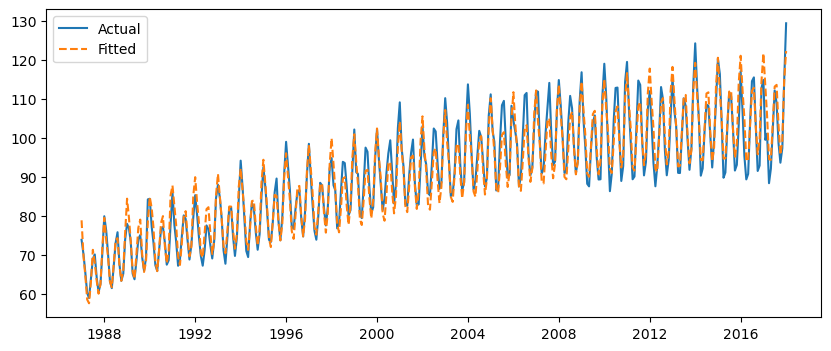

In [75]:
plt.figure(figsize=(10,4))
plt.plot(x.index,y, label='Actual')
plt.plot(x.index,lm.predict(x), 
         label = 'Fitted',linestyle='--')
plt.legend()
plt.show()